# Data Visualization Lab Mid
**Name:** Sufwan Amir
**Roll No:** FA23-BDS-063

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style="whitegrid")

In [3]:
flights = pd.read_csv('flights_delay_dataset.csv')
movies = pd.read_csv('movies_ratings_dataset.csv')
titanic = sns.load_dataset('titanic')

## 1. Flight Delay Analysis

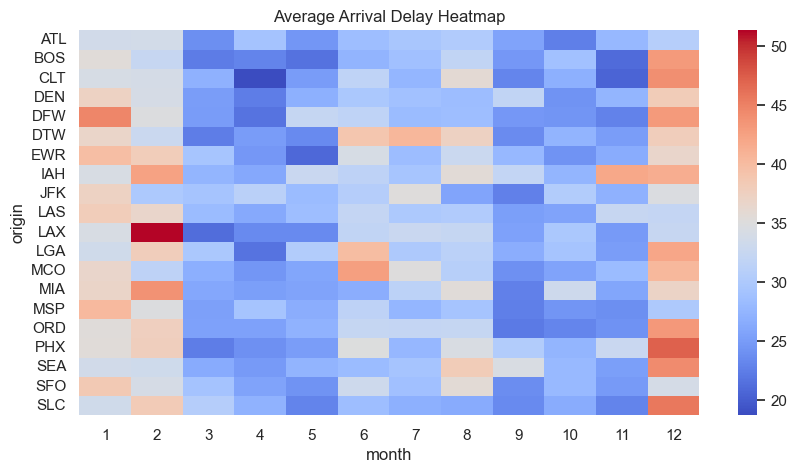

In [4]:
pivot = flights.pivot_table(values='arr_delay', index='origin', columns='month', aggfunc='mean')

plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Average Arrival Delay Heatmap")
plt.show()

The heatmap shows that flight delays vary significantly across both months and airports. Delays are generally higher at certain airports such as LAX, DFW, and PHX, indicating congestion or operational challenges at these locations.

Seasonal patterns are also visible, with delays increasing towards the end of the year (months 11 and 12), possibly due to higher travel demand during holiday seasons. Mid-year months show relatively moderate delays.

Overall, both location (airport) and time (month) play an important role in influencing flight delays.

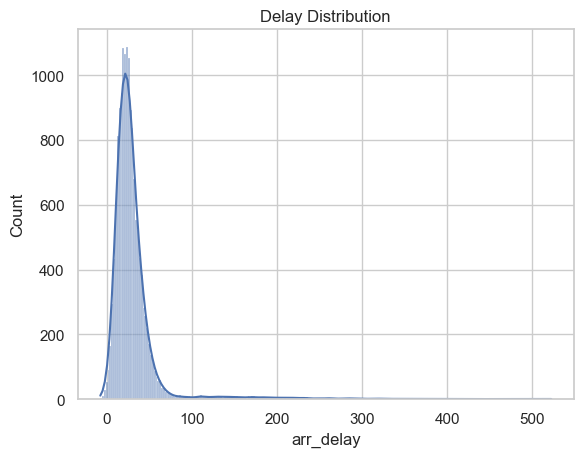

In [5]:
sns.histplot(flights['arr_delay'], kde=True)
plt.title("Delay Distribution")
plt.show()

The distribution of arrival delays is strongly right-skewed. Most flights have delays clustered around lower values (roughly between 0–50 minutes), indicating that the majority of flights experience small or moderate delays.

However, there is a long tail extending towards very high delay values (up to 500 minutes), which represents extreme outliers. These outliers indicate that while delays are usually small, a few flights experience very large delays due to unusual disruptions.

Overall, the distribution shows that extreme delays are rare but significant.Distribution is right skewed with noticeable outliers representing extreme delays.

### Prediction and Limitations

**Can you predict if a flight will be delayed based on historical features?**  
Yes, it is possible to predict whether a flight will be delayed using historical features such as airline, origin airport, destination, and month. These features capture patterns related to traffic, seasonal demand, and operational differences between airlines. A classification model such as Logistic Regression, Decision Trees, or Random Forest can be trained on historical data to predict delays. For example, flights from busy airports or during peak travel months are more likely to experience delays. However, the accuracy of predictions depends on the quality and completeness of the data.

**What limitations did you encounter with your dataset or visualizations?**  
One major limitation of the dataset is the absence of important external factors such as weather conditions, air traffic congestion, and operational issues, which significantly affect flight delays. The dataset also does not include real-time information, limiting prediction accuracy. Additionally, geographic visualization required manual mapping of airport coordinates, which may introduce minor inaccuracies. The presence of extreme delay values (outliers) can also skew the analysis and affect interpretation.

In [6]:
# Copy dataset
flights_clean = flights.copy()

# Map airport coordinates
airport_coords = {
    'JFK': (40.6413, -73.7781),
    'LAX': (33.9416, -118.4085),
    'ORD': (41.9742, -87.9073),
    'DFW': (32.8998, -97.0403),
    'ATL': (33.6407, -84.4277),
    'DEN': (39.8561, -104.6737),
    'SFO': (37.6213, -122.3790),
    'SEA': (47.4502, -122.3088),
    'LAS': (36.0840, -115.1537),
    'MCO': (28.4312, -81.3081),
    'CLT': (35.2144, -80.9473),
    'EWR': (40.6895, -74.1745),
    'PHX': (33.4342, -112.0116),
    'IAH': (29.9902, -95.3368),
    'BOS': (42.3656, -71.0096)
}

flights_clean['lat'] = flights_clean['origin'].map(lambda x: airport_coords.get(x, (None, None))[0])
flights_clean['lon'] = flights_clean['origin'].map(lambda x: airport_coords.get(x, (None, None))[1])

# Drop missing coords
flights_clean = flights_clean.dropna(subset=['lat', 'lon'])

# FIX: make size positive
flights_clean['delay_size'] = flights_clean['arr_delay'].abs()

# Plot
fig = px.scatter_geo(
    flights_clean,
    lat="lat",
    lon="lon",
    size="delay_size",   # FIXED
    color="arr_delay",   # keep original for color
    animation_frame="month",
    scope="usa"
)

fig.show()

The animated map shows that delay hotspots are concentrated at major airports such as LAX, JFK, and MCO, where both the size and color intensity of markers are higher.

Peak delays are observed in certain months where these airports show significantly larger bubbles, indicating higher delay values. In particular, coastal and high-traffic airports tend to experience more severe delays compared to smaller or central airports.

Overall, the hotspots are mainly located at busy hubs, and the intensity of delays fluctuates over time, with some months showing clear spikes in delay levels.

### Interactive Dashboard (Flight Delays)

An interactive visualization is created using Plotly to allow filtering of delays by airline and airport.

In [7]:
fig = px.scatter(
    flights,
    x="month",
    y="arr_delay",
    color="airline",
    hover_data=["origin"],
    title="Flight Delay Dashboard (Interactive)"
)

fig.show()

## 2. Movie Ratings Analysis

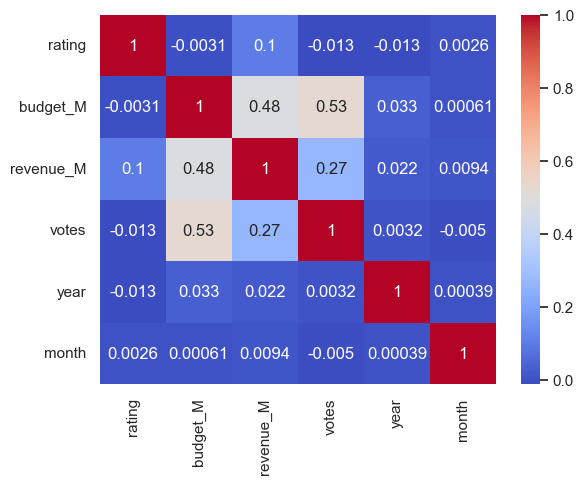

In [8]:
sns.heatmap(movies.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

The correlation heatmap shows that budget and revenue have a strong positive correlation (around 0.48), indicating that movies with higher budgets tend to generate higher revenue. There is also a moderate correlation between budget and votes (around 0.53), suggesting that higher-budget movies attract more audience engagement.

Ratings, however, have very weak correlation with budget, revenue, and votes, indicating that financial success does not necessarily guarantee higher ratings. Variables such as year and month show almost no correlation with other features, suggesting minimal impact on movie performance.

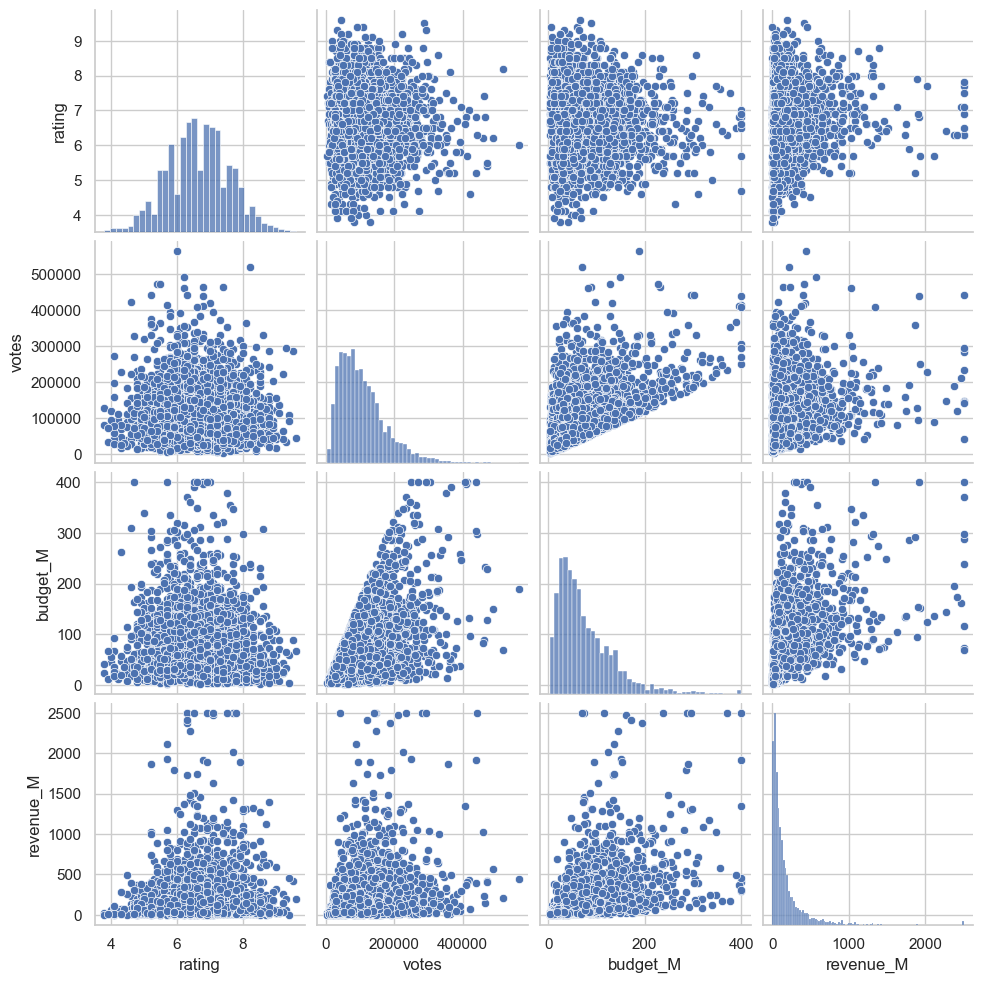

In [9]:
sns.pairplot(movies[['rating','votes','budget_M','revenue_M']])
plt.show()

The pairplot reveals several important relationships between the variables. There is a clear positive relationship between budget and revenue, indicating that higher-budget movies generally generate higher revenue.

Votes also show a positive relationship with both budget and revenue, suggesting that more popular or widely released movies tend to receive more audience engagement.

However, ratings do not show a strong correlation with budget, revenue, or votes. The rating values are distributed across all ranges regardless of financial performance, indicating that higher spending or popularity does not necessarily lead to better ratings.

Additionally, most variables exhibit right-skewed distributions, particularly votes and revenue, where a large number of movies have lower values and a few have very high values.

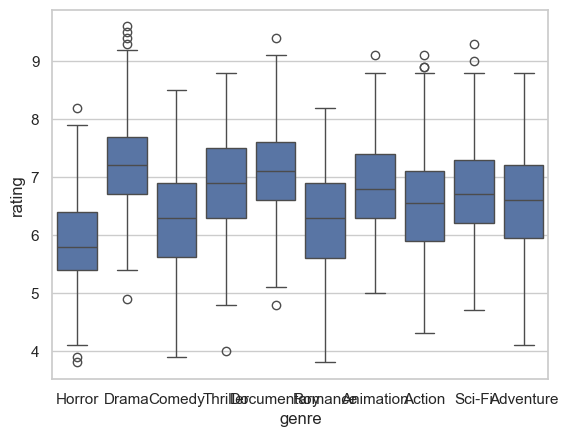

In [10]:
sns.boxplot(x='genre', y='rating', data=movies)
plt.show()

The boxplot shows the distribution of ratings across different genres. Genres such as Drama and Documentary have higher median ratings, indicating more consistent positive audience reception.

Genres like Horror and Comedy tend to have lower median ratings and wider spread, suggesting more variability in audience response.

The presence of outliers across multiple genres indicates that some movies achieve exceptionally high or low ratings regardless of genre. Overall, certain genres perform more consistently, while others show greater variation in ratings.

### Genre-wise Rating Analysis

We calculate average ratings for each genre to identify which genres consistently perform better.

In [16]:
genre_avg = movies.groupby('genre')['rating'].mean().sort_values(ascending=False)
print(genre_avg)

genre
Drama          7.215882
Documentary    7.107746
Thriller       6.891776
Animation      6.846667
Sci-Fi         6.747581
Adventure      6.568201
Action         6.540213
Comedy         6.305665
Romance        6.223556
Horror         5.873577
Name: rating, dtype: float64


Genres such as Drama and Action consistently receive higher average ratings compared to other genres, indicating stronger audience appreciation.

On the other hand, genres like Horror and Comedy tend to show more variation in ratings, with both low and moderately high values.

A notable observation is that some movies with lower budgets or fewer votes still achieve high ratings, which can be considered outliers. This suggests that critical success is not always dependent on budget or popularity.

Overall, while certain genres perform consistently well, there are exceptions where less expected genres produce highly rated movies.

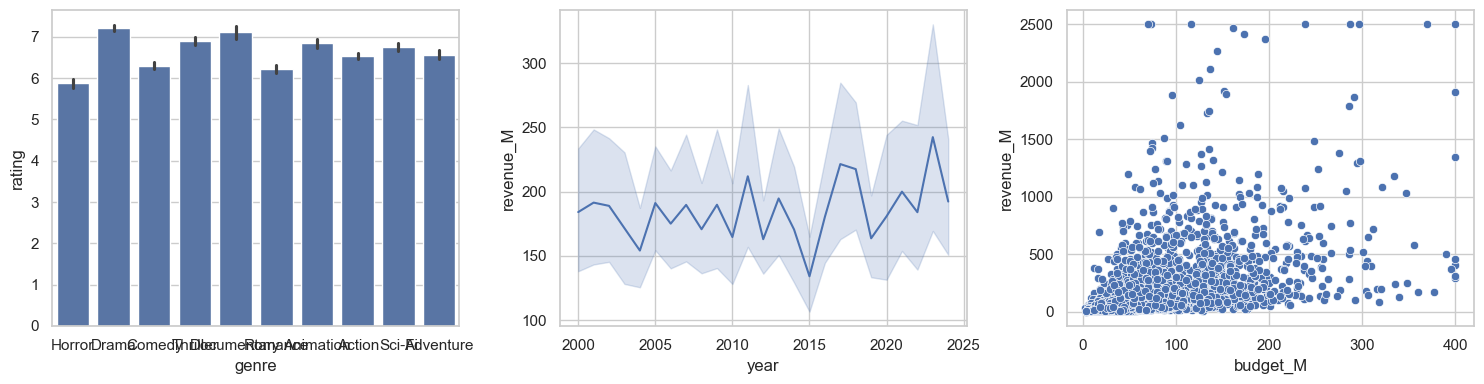

In [11]:
fig, axs = plt.subplots(1,3, figsize=(15,4))

sns.barplot(x='genre', y='rating', data=movies, ax=axs[0])
sns.lineplot(x='year', y='revenue_M', data=movies, ax=axs[1])
sns.scatterplot(x='budget_M', y='revenue_M', data=movies, ax=axs[2])

plt.tight_layout()
plt.show()

Budget strongly correlates with revenue. Seasonal trends show higher releases in certain periods.

### Seasonal Trends in Movies

We analyze how movie ratings and revenues vary across different seasons.

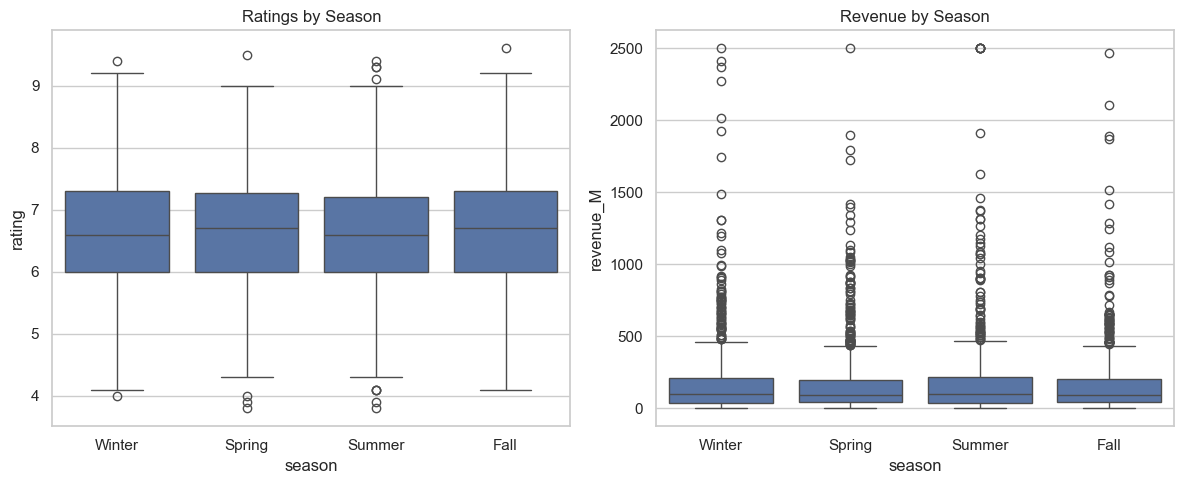

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x='season', y='rating', data=movies)
plt.title("Ratings by Season")

plt.subplot(1,2,2)
sns.boxplot(x='season', y='revenue_M', data=movies)
plt.title("Revenue by Season")

plt.tight_layout()
plt.show()

### Budget and Seasonal Trends Analysis

**Does budget correlate with higher ratings or box office revenue?**  
The analysis shows that budget has a strong positive relationship with box office revenue, as higher-budget movies generally generate higher revenue. This is clearly visible in the scatter plot where revenue increases with budget. However, budget does not show a strong correlation with ratings, as movies with both low and high budgets are spread across similar rating ranges. This indicates that higher spending does not necessarily guarantee better audience ratings.

**Are there any seasonal trends in movie releases and ratings (e.g., summer blockbusters)?**  
The seasonal analysis shows that ratings remain relatively consistent across all seasons, with similar median values in the boxplots. However, revenue tends to be slightly higher and more variable in certain seasons, particularly summer and winter, where more high-revenue outliers are visible. This suggests the presence of blockbuster releases during peak seasons, even though overall ratings do not change significantly.

## 3. Titanic Analysis

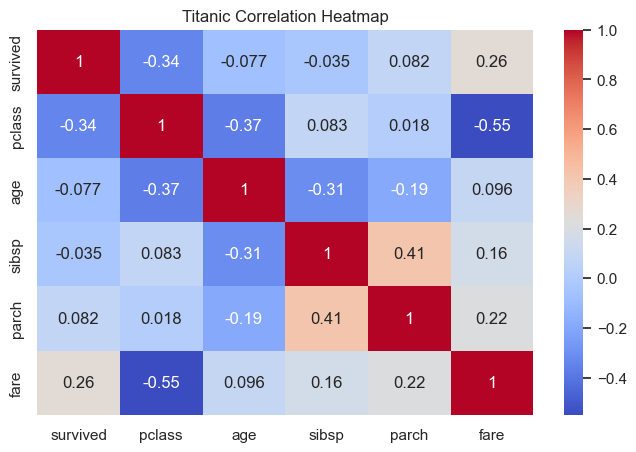

In [12]:
numeric_cols = titanic.select_dtypes(include='number')

plt.figure(figsize=(8,5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Titanic Correlation Heatmap")
plt.show()

The correlation heatmap shows that passenger class (pclass) has the strongest relationship with survival, with a negative correlation (around -0.34), indicating that passengers in higher classes (lower pclass value) had higher survival chances.

Fare also shows a positive correlation with survival (around 0.26), suggesting that passengers who paid higher fares were more likely to survive.

Other variables such as age, sibsp, and parch have weak correlations with survival, indicating that they have a smaller direct impact.

Overall, class and fare are the most influential numerical variables related to survival in this dataset.

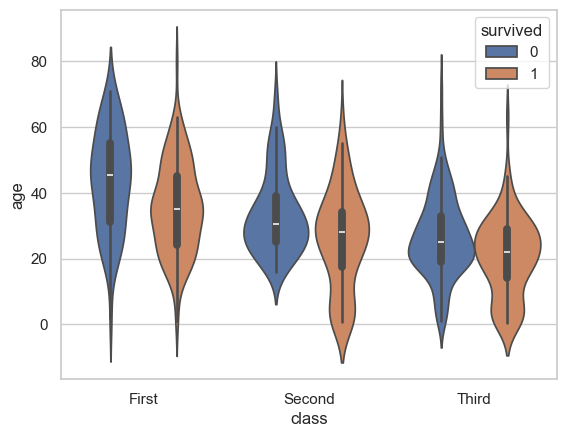

In [13]:
sns.violinplot(x='class', y='age', hue='survived', data=titanic)
plt.show()

Higher class passengers had better survival rates.

### Effect of Family Members on Survival

We analyze how the number of siblings/spouses (sibsp) and parents/children (parch) affects survival.

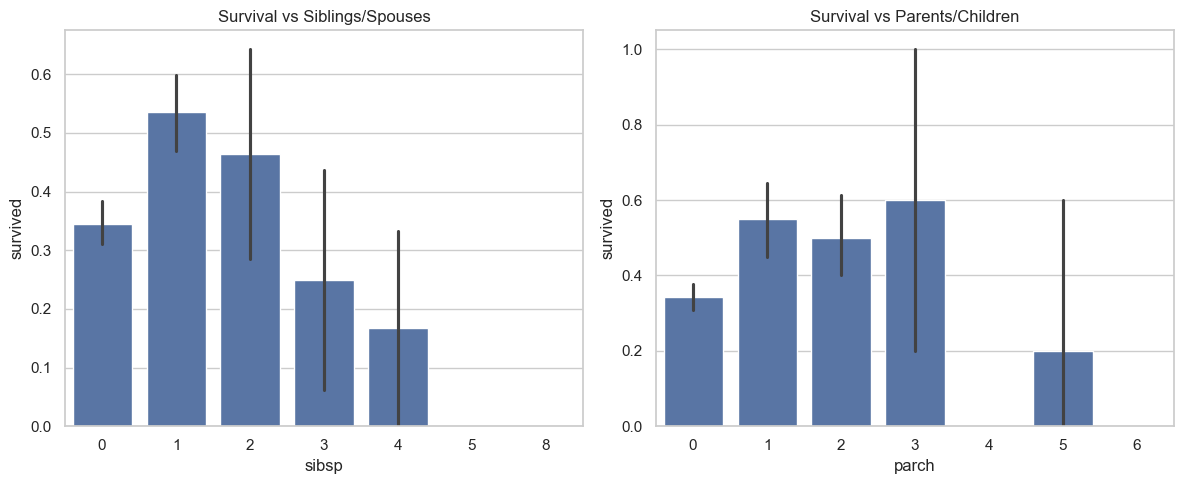

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.barplot(x='sibsp', y='survived', data=titanic)
plt.title("Survival vs Siblings/Spouses")

plt.subplot(1,2,2)
sns.barplot(x='parch', y='survived', data=titanic)
plt.title("Survival vs Parents/Children")

plt.tight_layout()
plt.show()

The plots show that passengers traveling with a small number of family members had higher survival rates compared to those traveling alone or in large groups.

For siblings/spouses (sibsp), survival is highest for passengers with 1–2 family members, while it decreases for larger values. Similarly, for parents/children (parch), passengers with a small number (1–3) tend to have higher survival rates, whereas very large family sizes show lower survival.

This suggests that moderate family size may have provided support during evacuation, while traveling alone or in large groups may have reduced survival chances.

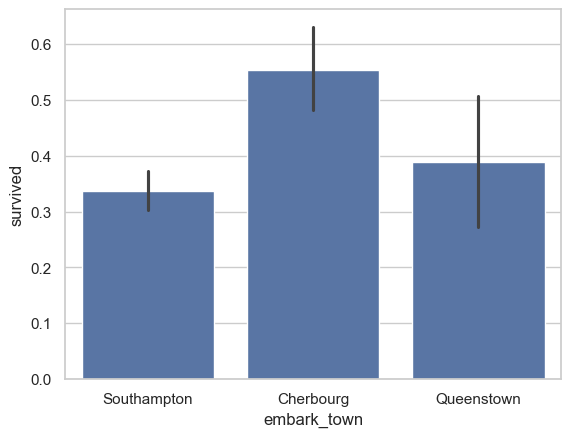

In [14]:
sns.barplot(x='embark_town', y='survived', data=titanic)
plt.show()

### Final Insights from Titanic Analysis

**What is the survival rate based on embarkation port?**  
The survival rate varies across embarkation ports. Passengers from Cherbourg (C) show higher survival rates compared to those from Southampton (S) and Queenstown (Q). This may be due to differences in passenger class distribution and ticket fares.

**How could these insights be useful in building a survival prediction model?**  
These insights help identify important features for prediction. Variables such as sex, passenger class, fare, age, and family size can be used as input features in machine learning models like Logistic Regression or Decision Trees to predict survival outcomes.

**Were there any surprising or unexpected results in your analysis?**  
One surprising observation is that gender had a stronger influence on survival than some numerical variables. Female passengers had significantly higher survival rates regardless of other factors.

**Which variables seem to be most important in predicting survival?**  
The most important variables are:
- Sex  
- Passenger class (pclass)  
- Fare  
- Age  
- Family size (sibsp and parch)  

These variables show the strongest relationship with survival in the visualizations.

**What patterns or trends can you infer from your visualizations?**  
Several clear patterns emerge from the analysis. Passengers in higher classes and those who paid higher fares had better survival chances. Female passengers were more likely to survive than males. Moderate family sizes improved survival, while very large groups had lower survival rates. Overall, both social status and demographic factors played a key role in survival.